<a href="https://colab.research.google.com/github/danielchin-ck/ADALL_github/blob/main/Copy_of_6096089W_CDA1C03_ADALL_Project_2026_Ver3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Libraries used in this notebook
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

In [ ]:
# No need to run
import os
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
assert token, 'Missing Colab Secret: GITHUB_TOKEN'

os.environ['GITHUB_TOKEN'] = token
os.environ['GITHUB_USER'] = 'danielchin-ck'
os.environ['GITHUB_REPO'] = 'ADALL_github'
os.environ['GITHUB_EMAIL'] = 'danielchin.ck@gmail.com'

print('GitHub settings loaded. Token is not printed.')

In [ ]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')



OpenAI client is ready.


In [ ]:
#Version 1
bp_prompt = f"""
You are a Data Scientist of specialized experience in tree-based regression models (XGBoost, LightGBM, Random Forest) for actuarial and real-estate forecasting.
Your expertise is translating ambiguous socio-economic problems into rigorous ML objectives with clear business impact.

CONTEXT:
Mr. Chin faces a criticial retirement challenge: his Executive Apartment HDB flat is depreciating through lease decay, but a new MRT station near his flat will be completed after 2029,
potentially boosting its value. He needs to identify the optimal year within the next 5 to 10 years to downsize - balancing these opposite forces.

YOUR TASK:
Craft a complete ML modelling brief that addresses the following:

1. BUSINESS PROBLEM DEFINITION
   •	Describe the business problem you aim to address. Explain why it matters and who is affected.

2. PRIMARY BENEFICIARY PERSONA
   •	Identify the key beneficiary of the ML solution. Create a simple persona that captures details important for this project,
   such as the person’s goals, pain points, behaviours and how they would use the solution.

3. JTBD-FRAMED MODELLING OBJECTIVES
   •	Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives. State the job the user is trying to complete,
   and define your target variable and likely predictors based on this job.

FORMAT:
Respond in point forms

CONSTRAINTS:
Keep it concise and to the point.
Limit each section to maximum 200 characters per line.
"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=bp_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
- **1) BUSINESS PROBLEM DEFINITION**
  - **Problem:** Forecast best downsizing year (next 5–10y) for HDB Exec apartment.
  - **Why it matters:** Flat value decays via lease term + may rise after new MRT completion.
  - **Impact:** Helps avoid overpaying on timing; reduces retirement risk for household cashflow.
  - **Affected:** Mr. Chin + co-owners; retirement planning; potential buyers/estate liquidity.

- **2) PRIMARY BENEFICIARY PERSONA**
  - **Persona:** “Kian Chin, 55–62, nearing retirement, owns Executive HDB.”
  - **Goal:** Choose downsizing year to maximize proceeds (or minimize loss) while maintaining housing stability.
  - **Pain points:** Unclear MRT price lift timing; uncertainty on lease decay vs transit premium.
  - **Behaviour:** Uses online price trends; waits for “right time”; needs a data-backed decision rule.
  - **Use:** Inputs address/lease/financial constraints → gets recommended year range + rationale.

- **3) JTBD-FRAMED MODELLING OBJECTIVES**
  

In [ ]:
#Version 2
bp_prompt = f"""
You are a Data Scientist of specialized experience in tree-based regression models (XGBoost, LightGBM, Random Forest) for actuarial and real-estate forecasting.
Your expertise is translating ambiguous socio-economic problems into rigorous ML objectives with clear business impact.

CONTEXT:
Mr. Chin faces a criticial retirement challenge: his 36 years old Executive Apartment HDB flat is depreciating through lease decay, but a new MRT station near his flat will be completed after 2029,
potentially boosting its value. He needs to identify the optimal year within the next 5 to 10 years to downsize - balancing these opposite forces.

YOUR TASK:
Craft a complete ML modelling brief that addresses the following:

1. BUSINESS PROBLEM DEFINITION
   •	Describe the business problem you aim to address. Explain why it matters and who is affected.

2. PRIMARY BENEFICIARY PERSONA
   •	Identify the key beneficiary of the ML solution. Create a simple persona that captures details important for this project,
   such as the person’s goals, pain points, behaviours and how they would use the solution.

3. JTBD-FRAMED MODELLING OBJECTIVES
   •	Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives. State the job the user is trying to complete,
   and define your target variable and likely predictors based on this job.

FORMAT:
Respond in point forms

CONSTRAINTS:
Keep it concise and to the point.
Limit each section to maximum 200 characters per line.
"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=bp_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
- **1) Business Problem Definition**
  - Optimize best downsize timing (year) for an HDB Executive Apartment lease decay vs MRT value uplift.
  - Affects Mr. Chin’s retirement capital planning and housing affordability risk.
  - Deliver decision support: “Downsize year” choice within next 5–10 yrs.

- **2) Primary Beneficiary Persona**
  - **Persona:** 36yo owner-occupier of Exec Apartment HDB, planning retirement in 10–20 yrs.
  - **Goal:** Sell, downsize, and fund retirement while minimizing loss/overpay risk.
  - **Pain points:** Lease decay drag; uncertainty about MRT-driven uplift timing; limited time to analyze.
  - **Usage:** Inputs property + household + timeline; receives best year + expected value range.

- **3) JTBD-Framed Modelling Objectives**
  - **JTBD:** “Help me choose the year to sell/downsize so my net proceeds + affordability are maximized.”
  - **Target variable (regression):**
    - Predict **HDB resale price** (or **net proceeds**) by candidate yea

In [ ]:
prepare_prompt = f"""
You are a Data Scientist of specialized experience in tree-based regression models (XGBoost, LightGBM, Random Forest) for actuarial and real-estate forecasting.

CONTEXT:
When Mr. Chin’s HDB Executive Apartment in Pasir Ris approaches the post-MRT era (2030 onwards) and he need to fund his retirement, he want to identify the best year within 2030–2036 to downsize, so that he can maximize his net sale proceeds by capturing the Cross Island Line MRT premium before lease decay erodes his flat's value.“

Target Variable (Regression)
Primary Target:
Projected Net Sale Proceeds (selling price) for each candidate year t, where t ∈ [2030, 2031, ..., 2036].

Key Assumptions:
✅ Nominal proceeds only (no discounting)
✅ No P10/P50 guardrails or probabilistic optimization
✅ MRT operational by 2030 (no time covariates needed)
Per Straits Times (23 Mar 2026), MRT premium decay of $54,027 per 100m applies only beyond 400m. Since Mr. Chin's flat is at 200m, I have applied the full premium $54,027 with no decay.

Predictors (Feature Set):
Property Attributes: Remaining lease (months/years), flat age, floor level, unit size (m²), town (Pasir Ris), precinct proxies, flat type
Location/MRT: Distance to MRT (200m), baseline accessibility, MRT premium
Market Dynamics: Historical resale price index (town-level), recent transacted m² in Pasir Ris, resale supply trends

Excluded Predictors:
❌ Time covariates (year index t, event indicators for MRT phases) — MRT operational by 2030
❌ Macro variables (interest rates, wage growth, inflation) — outside scope

Dataset: 	https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv

YOUR TASK:
Provide a clear a overview of how you prepared and modelled your data. You should describe the important choices you made, especially those that shape how the model behaves or how the results should be interpreted. You do not need to repeat every step of your code. Focus instead on what a decision maker needs to know when judging whether the solution is trustworthy and practical. You can consider covering the following with relevant screenshots of code and/or visualisation, including but not limited to:
•	Transforming predictors to uncover useful patterns
•	Balancing imbalance classes, if applicable
•	Modelling choices made

Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives. State the job the user is trying to complete,
and define your target variable and likely predictors based on this job.

Generate code using Python.

"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=prepare_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
Below is an overview you can use in a decision-maker–friendly “model preparation & modelling” section. I’ll frame it with the JTBD job, explain the modelling choices that materially affect behaviour, and include Python code snippets showing key transformations and how the model is trained for each candidate year 2030–2036.

---

## 1) JTBD framing (what Mr. Chin is trying to do)

**Job-to-be-Done:**  
Mr. Chin wants to choose the *best year between 2030 and 2036* to downsize so that he **maximizes his expected net sale proceeds**, by capturing the **Cross Island Line MRT premium** while not suffering (lease-decay–driven) erosion of his flat’s value.

**Decision output needed:**  
For each candidate year \(t \in \{2030, 2031, \dots, 2036\}\), estimate **Projected Net Sale Proceeds**. Then select the maximizing year.

---

## 2) Target variable and how it maps to ML

### Primary target (regression)
For each record in the training data (historical resale transactions), the 

In [ ]:
# Libraries used in this notebook
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries used later in Session 2
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

In [ ]:
github_raw_url = "https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (237194, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [ ]:
buss_prompt = f"""

You are an expert data scientist with experience in tree-based regression models.
Help me translate this business problem into a modelling objective.

Business problem: Mr. Chin faces a criticial retirement challenge: his 36 years old Executive Apartment HDB flat is depreciating through lease decay,
but a new MRT station near his flat will be completed after 2029,potentially boosting its value. He needs to identify the optimal year within the next 5 to 10 years to downsize - balancing these opposite forces.

Dataset context: {df}

Please answer:

1. What should the modelling objective be?
2. What is the most meaningful target column?
3. Which metric would be easiest to explain to business users?
4. Who are the main stakeholders?
5. What are three risks or pitfalls?

Respond in point forms

CONSTRAINTS:
Keep it concise and to the point.
Limit each section to maximum 200 characters per line.
"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=buss_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
1) **Modelling objective**
- Predict future resale price for each flat at candidate years (next 5–10 yrs).
- Choose **optimal downsizing year** that maximizes expected sale proceeds (or net gain vs holding).

2) **Most meaningful target column**
- **resale_price** (price at observation month).
- For year-choice: model **resale_price at future year** using remaining_lease, macro time, and station-boost features.

3) **Easiest metric to explain to business users**
- **MAPE of resale_price** (% error).
- Alternative: **RMSE** (dollar error) if users prefer $ impact.

4) **Main stakeholders**
- Mr. Chin (personal decision-maker).
- HDB/real-estate advisors & mortgage/financial planners.
- Data/analytics team building the model.
- Policy/urban planners indirectly (MRT impact assumptions).

5) **Three risks / pitfalls**
- **Data leakage**: using post-event price info when predicting pre-event.
- **Non-causality**: MRT proximity correlations ≠ true station effect.
- **Time shif

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237194 entries, 0 to 237193
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                237194 non-null  object 
 1   town                 237194 non-null  object 
 2   flat_type            237194 non-null  object 
 3   block                237194 non-null  object 
 4   street_name          237194 non-null  object 
 5   storey_range         237194 non-null  object 
 6   floor_area_sqm       237194 non-null  float64
 7   flat_model           237194 non-null  object 
 8   lease_commence_date  237194 non-null  int64  
 9   remaining_lease      237194 non-null  object 
 10  resale_price         237194 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.9+ MB


In [ ]:
df.columns.tolist()

['month',
 'town',
 'flat_type',
 'block',
 'street_name',
 'storey_range',
 'floor_area_sqm',
 'flat_model',
 'lease_commence_date',
 'remaining_lease',
 'resale_price']

In [ ]:
data_preview = df.head(10).to_string()
print(data_preview[:1500])

     month        town flat_type block        street_name storey_range  floor_area_sqm      flat_model  lease_commence_date     remaining_lease  resale_price
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12            44.0        Improved                 1979  61 years 04 months      232000.0
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03            67.0  New Generation                 1978  60 years 07 months      250000.0
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years 05 months      262000.0
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06            68.0  New Generation                 1980   62 years 01 month      265000.0
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years 05 months      265000.0
5  2017-01  ANG MO KIO    3 ROOM   150   ANG MO KIO 

In [ ]:
preview_prompt = f"""

Here are the first 10 rows of HDB resale pricing dataset:

{data_preview}

Questions:
1. What does each row appear to represent?
2. Which column is likely the target for a price prediction model?
3. What are 3 possible data quality checks we should perform before modelling?

Keep the answer short and practical.
"""

print('Prompt to send:')
print(preview_prompt[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=preview_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

Prompt to send:


Here are the first 10 rows of HDB resale pricing dataset:

     month        town flat_type block        street_name storey_range  floor_area_sqm      flat_model  lease_commence_date     remaining_lease  resale_price
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12            44.0        Improved                 1979  61 years 04 months      232000.0
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03            67.0  New Generation                 1978  60 years 07 months      250000.0
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years 05 months      262000.0
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06            68.0  New Generation                 1980   62 years 01 month      265000.0
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years

In [ ]:
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 3. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 4. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 5. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 6. Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 7. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 8. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)

payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
payload_text += 'Duplicate rows: ' + str(df.duplicated().sum()) + '\n'

print(payload_text)

# This cell builds a short dataset profile called payload_text.
# Instead of sending the full dataset to the LLM, we send summary information only.
# The payload includes shape, column types, numeric summary, missing values, unique counts, correlations, and common category values.
# It also adds simple warning checks for possible ID-like columns, constant columns, and duplicate rows.
# This helps the LLM comment on data readiness without needing every row of the dataset.

=== SHAPE ===
Rows: 237194
Columns: 11

=== COLUMNS AND DATA TYPES ===
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64

=== NUMERIC SUMMARY ===
       floor_area_sqm  lease_commence_date  resale_price
count       237194.00            237194.00     237194.00
mean            96.69              1996.59     533134.98
std             24.02                14.38     191348.81
min             31.00              1966.00     140000.00
25%             81.00              1985.00     390000.00
50%             93.00              1997.00     500000.00
75%            112.00              2012.00     640000.00
max            366.70              2022.00    1728000.00

=== MISSING VALUES ===
                     missi

In [ ]:
quality_prompt = f"""
You are helping a data analytics student prepare a HDB resale pricing dataset for modelling.

Dataset profile:
{payload_text}

Task:
1. List all data quality or modelling-readiness issues.
2. Suggest action to remedy the issues.

Important:
- Do not assume external knowledge.
- Do not say to drop a column just because it is listed as a warning.
- Keep the answer concise.
"""


if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell asks the LLM to review the dataset profile for modelling-readiness issues.
# The LLM does not receive the full dataset, only the summary stored in payload_text.
# The prompt asks for possible issues and practical remedies.
# The instructions help prevent the LLM from making unsupported assumptions or dropping columns too quickly.
# If the API client is connected, the prompt is sent automatically.
# Otherwise, students can copy the prompt and use the chatbot manually.


LLM response:
## 1) Data quality / modelling-readiness issues

1. **Duplicate rows present**
   - `Duplicate rows: 316` (no further detail given)
   - Risk: inflates sample size and can bias model training/evaluation.

2. **High-cardinality categorical features**
   - `block` (2775 unique), `street_name` (578), `month` (116), `remaining_lease` (702)
   - Risk: severe dimensionality increase (especially with one-hot encoding), sparsity, overfitting.

3. **Potentially non-numeric “lease” representation**
   - `remaining_lease` is **object** with values like `"94 years 10 months"`
   - Risk: not directly usable for numeric modelling; ordering/interval relationships may be unclear.

4. **Imperfect / ambiguous temporal fields**
   - `month` is **object** (116 unique) and there is also `lease_commence_date` (int)
   - Risk: if `month` ordering is not parsed correctly as a date/time index, time-based validation and trend features may be wrong.

5. **“Lease commence date” granularity may be c

In [ ]:
quality_prompt = f"""
You are helping a data analytics student prepare a HDB resale pricing dataset for modelling.

Dataset profile:
{payload_text}

Task:
1. Provide Python code to list all duplicate rows for observation.

Important:
- Do not assume external knowledge.
- Do not say to drop a column just because it is listed as a warning.
- Keep the answer concise.
"""


if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
```python
import pandas as pd

# df = your DataFrame

# 1) Find duplicate rows (exact duplicates across all columns)
dup_mask = df.duplicated(keep=False)
dup_rows = df.loc[dup_mask].sort_values(list(df.columns))  # optional sort for readability

# 2) List them
print(f"Number of rows that are part of duplicate sets: {dup_rows.shape[0]}")
print(dup_rows)

# (Optional) If you want each duplicate set grouped and printed with counts:
# print(df[dup_mask].groupby(list(df.columns)).size().reset_index(name="count"))
```


In [ ]:
import pandas as pd

# df = your dataframe (must contain the 11 columns shown)

# Find duplicate rows (entire-row duplicates)
dup_mask = df.duplicated(keep=False)  # marks all occurrences of duplicates

dup_rows = df.loc[dup_mask].copy()

print(f"Number of duplicate-row records (including all copies): {len(dup_rows)}")
print("Duplicate rows (all columns):")
print(dup_rows)

Number of duplicate-row records (including all copies): 631
Duplicate rows (all columns):
          month          town flat_type block       street_name storey_range  \
224     2017-01   BUKIT MERAH    4 ROOM   106    HENDERSON CRES     07 TO 09   
243     2017-01   BUKIT MERAH    4 ROOM   106    HENDERSON CRES     07 TO 09   
304     2017-01  CENTRAL AREA    3 ROOM   271          QUEEN ST     16 TO 18   
305     2017-01  CENTRAL AREA    3 ROOM   271          QUEEN ST     16 TO 18   
505     2017-01   JURONG EAST    4 ROOM   265       TOH GUAN RD     04 TO 06   
...         ...           ...       ...   ...               ...          ...   
232828  2026-03      SENGKANG    5 ROOM  224C  COMPASSVALE WALK     07 TO 09   
234808  2026-03     TOA PAYOH    4 ROOM  103B    BIDADARI PK DR     07 TO 09   
234811  2026-03     TOA PAYOH    4 ROOM  103B    BIDADARI PK DR     07 TO 09   
235207  2026-04     WOODLANDS    3 ROOM   148   WOODLANDS ST 13     01 TO 03   
235208  2026-04     WOODLANDS 

In [ ]:
import pandas as pd
import numpy as np

# Make a copy to preserve the original df
cleaned_df = df.copy()

# 1. Handle duplicate rows
# Remove exact duplicate rows
initial_rows = len(cleaned_df)
cleaned_df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(cleaned_df)} duplicate rows.")

# 2. Reduce/encode high-cardinality categoricals appropriately
# Filter the town to 'Pasir Ris' and flat_type to 'Executive' and flat_model to 'Apartment'
cleaned_df = cleaned_df[cleaned_df['town'].str.upper() == 'PASIR RIS']
cleaned_df = cleaned_df[cleaned_df['flat_type'].str.upper() == 'EXECUTIVE']
cleaned_df = cleaned_df[cleaned_df['flat_model'].str.upper() == 'APARTMENT']
print(f"Filtered to 'Pasir Ris' town,'Executive' flat_type and 'Apartment' flat_model. Remaining rows: {len(cleaned_df)}")

# 4. Ensure time parsing for 'month' and create 'transacted-year'
cleaned_df['month'] = pd.to_datetime(cleaned_df['month'])
cleaned_df['transaction_year'] = cleaned_df['month'].dt.year
cleaned_df['transaction_month_num'] = cleaned_df['month'].dt.month # Keep month number for potential seasonality
# As per instruction 'consider to drop [month]' and 'replace the month' with 'transacted-year'
cleaned_df.drop('month', axis=1, inplace=True)

# 3. Convert `remaining_lease` to numeric (whole years only, ignoring months)
def parse_remaining_lease_years(lease_str):
    if pd.isna(lease_str):
        return np.nan
    lease_str = str(lease_str).lower()
    years = 0
    if 'year' in lease_str:
        year_part = lease_str.split('year')[0].strip()
        try:
            years = int(year_part)
        except ValueError:
            pass # Handle cases where year_part might not be an integer
    return years

cleaned_df['remaining_lease_years'] = cleaned_df['remaining_lease'].apply(parse_remaining_lease_years)

# 5. Create “lease age (yrs)” features: years_since_commence (as whole number)
# Calculate current age of the flat at the time of transaction
# 'lease_commence_date' is int representing year, 'transaction_year' is also int
cleaned_df['age_of_flat_at_transaction'] = cleaned_df['transaction_year'] - cleaned_df['lease_commence_date']

# 8. Sanity checks for categorical consistency (trim whitespace, standardize casing)
categorical_cols_to_clean = ['town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model']
for col in categorical_cols_to_clean:
    if col in cleaned_df.columns and cleaned_df[col].dtype == 'object':
        cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.lower()

# 7. Feature engineering for price modelling: price_per_sqm
# Check for zero floor_area_sqm to avoid division by zero
if (cleaned_df['floor_area_sqm'] == 0).any():
    print("Warning: 'floor_area_sqm' contains zero values. Handling for 'price_per_sqm' calculation.")
    cleaned_df['price_per_sqm'] = cleaned_df.apply(lambda row: row['resale_price'] / row['floor_area_sqm'] if row['floor_area_sqm'] != 0 else np.nan, axis=1)
else:
    cleaned_df['price_per_sqm'] = cleaned_df['resale_price'] / cleaned_df['floor_area_sqm']

# 6. Outlier treatment (quantify and document, but do not modify at this stage as per instruction)
print("\n--- Outlier Detection Report (No modification performed) ---")
# Only consider columns that are expected to be numeric and relevant for outlier analysis
numeric_cols_for_outliers = ['floor_area_sqm', 'resale_price', 'remaining_lease_years', 'age_of_flat_at_transaction', 'price_per_sqm']

for col in numeric_cols_for_outliers:
    if col in cleaned_df.columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Count values outside the IQR bounds, ignoring NaNs
        outliers_count = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)][col].count()
        print(f"Column '{col}': {outliers_count} outliers detected (outside 1.5*IQR). Min: {cleaned_df[col].min():.2f}, Max: {cleaned_df[col].max():.2f}")
        if outliers_count > 0:
            # Print a few examples of outliers, handle potential empty slices
            example_outliers = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)][[col]].head()
            if not example_outliers.empty:
                print(f"  Example outliers for '{col}':\n{example_outliers.to_string()}")

# Function to parse storey_range and group it numerically
def get_storey_group(storey_range_str):
    if pd.isna(storey_range_str):
        return np.nan

    # The format is 'XX TO YY', convert to lower case first due to previous cleaning step
    try:
        # Extract the lower bound of the storey range
        lower_bound = int(storey_range_str.split(' to ')[0])
        # Grouping: 01-03 is group 1, 04-06 is group 2, etc.
        # (lower_bound - 1) // 3 + 1 will correctly map these
        return (lower_bound - 1) // 3 + 1
    except (ValueError, IndexError):
        return np.nan # Handle cases where parsing might fail

# Apply the function to create the new column
cleaned_df['storey_range_group'] = cleaned_df['storey_range'].apply(get_storey_group)

print("Added 'storey_range_group' column.")
#print("\n--- Updated Cleaned DataFrame Info ---")
#cleaned_df.info()
#print("\nUpdated Cleaned DataFrame head (with 'storey_range_group'):")
#print(cleaned_df[['storey_range', 'storey_range_group']].head().to_string())



print("\n--- Cleaned DataFrame Info ---")
cleaned_df.info()
print("\nCleaned DataFrame head:")
print(cleaned_df.head().to_string())

Removed 316 duplicate rows.
Filtered to 'Pasir Ris' town,'Executive' flat_type and 'Apartment' flat_model. Remaining rows: 1378

--- Outlier Detection Report (No modification performed) ---
Column 'floor_area_sqm': 20 outliers detected (outside 1.5*IQR). Min: 141.00, Max: 169.00
  Example outliers for 'floor_area_sqm':
       floor_area_sqm
705             161.0
7093            158.0
8947            158.0
19795           158.0
23791           159.0
Column 'resale_price': 0 outliers detected (outside 1.5*IQR). Min: 470500.00, Max: 1100000.00
Column 'remaining_lease_years': 0 outliers detected (outside 1.5*IQR). Min: 63.00, Max: 78.00
Column 'age_of_flat_at_transaction': 0 outliers detected (outside 1.5*IQR). Min: 21.00, Max: 36.00
Column 'price_per_sqm': 0 outliers detected (outside 1.5*IQR). Min: 3179.05, Max: 7452.05
Added 'storey_range_group' column.

--- Cleaned DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 1378 entries, 703 to 229984
Data columns (total 16 columns

In [ ]:
cleaned_df.head().

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,price_per_sqm,storey_range_group
703,pasir ris,executive,239,pasir ris st 21,10 to 12,147.0,apartment,1993,75 years 07 months,552888.0,2017,1,75,24,3761.142857,4
705,pasir ris,executive,237,pasir ris st 21,10 to 12,161.0,apartment,1993,75 years 06 months,600000.0,2017,1,75,24,3726.708075,4
1771,pasir ris,executive,644,pasir ris dr 10,01 to 03,143.0,apartment,1995,77 years 08 months,505000.0,2017,2,77,22,3531.468531,1
1772,pasir ris,executive,267,pasir ris st 21,01 to 03,148.0,apartment,1994,76 years 08 months,505000.0,2017,2,76,23,3412.162162,1
1773,pasir ris,executive,710,pasir ris st 72,04 to 06,146.0,apartment,1996,78 years 04 months,530000.0,2017,2,78,21,3630.136986,2


In [ ]:
# What to check after cleaning:
# 1. Did the number of rows stay the same?
# 2. Did the discount columns disappear?
# 3. Are there missing values that still need attention?
# 4. Does Price_SGD still exist as the target column?

print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

Original rows: 237194
Cleaned rows: 1378

Missing values after cleaning:


,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0
resale_price,0



Columns after cleaning:
['town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'transaction_year', 'transaction_month_num', 'remaining_lease_years', 'age_of_flat_at_transaction', 'price_per_sqm', 'storey_range_group']


In [ ]:
#Save to csv
cleaned_df.to_csv('cleaned_hdb_prices.csv', index=False)

print('Saved cleaned dataset as cleaned_hdb_prices.csv')


Saved cleaned dataset as cleaned_hdb_prices.csv


In [ ]:
print('Loaded cleaned_hdb_prices.csv.')
print('Cleaned shape:', cleaned_df.shape)
display(cleaned_df.head())

Loaded cleaned_hdb_prices.csv.
Cleaned shape: (1378, 16)


,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,price_per_sqm,storey_range_group
703,pasir ris,executive,239,pasir ris st 21,10 to 12,147.0,apartment,1993,75 years 07 months,552888.0,2017,1,75,24,3761.142857,4
705,pasir ris,executive,237,pasir ris st 21,10 to 12,161.0,apartment,1993,75 years 06 months,600000.0,2017,1,75,24,3726.708075,4
1771,pasir ris,executive,644,pasir ris dr 10,01 to 03,143.0,apartment,1995,77 years 08 months,505000.0,2017,2,77,22,3531.468531,1
1772,pasir ris,executive,267,pasir ris st 21,01 to 03,148.0,apartment,1994,76 years 08 months,505000.0,2017,2,76,23,3412.162162,1
1773,pasir ris,executive,710,pasir ris st 72,04 to 06,146.0,apartment,1996,78 years 04 months,530000.0,2017,2,78,21,3630.136986,2


In [ ]:
# Columns to remove due to data leakage or redundancy
columns_to_drop = ['remaining_lease', 'price_per_sqm', 'storey_range']

# Drop the identified columns from cleaned_df
# The target column 'resale_price' will be separated later when creating X and y.
cleaned_df.drop(columns=columns_to_drop, inplace=True)

print(f"Removed columns: {columns_to_drop}")
print("\n--- Cleaned DataFrame Info after column removal ---")
cleaned_df.info()
print("\nCleaned DataFrame head after column removal:")
print(cleaned_df.head().to_string())

Removed columns: ['remaining_lease', 'price_per_sqm', 'storey_range']

--- Cleaned DataFrame Info after column removal ---
<class 'pandas.core.frame.DataFrame'>
Index: 1378 entries, 703 to 229984
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1378 non-null   object 
 1   flat_type                   1378 non-null   object 
 2   block                       1378 non-null   object 
 3   street_name                 1378 non-null   object 
 4   floor_area_sqm              1378 non-null   float64
 5   flat_model                  1378 non-null   object 
 6   lease_commence_date         1378 non-null   int64  
 7   resale_price                1378 non-null   float64
 8   transaction_year            1378 non-null   int32  
 9   transaction_month_num       1378 non-null   int32  
 10  remaining_lease_years       1378 non-null   int64  
 11  age_of_flat_at_transactio

In [ ]:
# 1. Load Historical Resale Price Index
price_index_url = "https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/Executive_Resale_Price_Index%20%E2%80%93%202007%20Q1%20to%202026%20Q2.csv"
historical_price_index_df = pd.read_csv(price_index_url)

# Ensure the 'Year' column is integer for merging/analysis
historical_price_index_df['Year'] = historical_price_index_df['Year'].astype(int)

print("Historical Resale Price Index loaded.")
print(historical_price_index_df.head())

# 2. Define MRT Premium Constant
MRT_PREMIUM = 54027.0
print(f"\nMRT Premium constant set to: ${MRT_PREMIUM:,.2f}")

# 3. Define Placeholder for Lease Decay (balaRatio(T))
# Reconstructing the calculate_lease_decay function with the provided balaRatio formula.
def calculate_lease_decay(remaining_lease_years):
    """
    Calculate the Bala Ratio based on the formula:
    Bala(T) = 1 - (1 / 1.035)^T

    Parameters:
    - remaining_lease_years: int or float, number of years remaining on the lease

    Returns:
    - float: the Bala Ratio (percentage of freehold value retained)
    """
    if remaining_lease_years <= 0:
        return 0.0
    return 1 - (1 / 1.035) ** remaining_lease_years

print("\n`calculate_lease_decay` function updated with the provided Bala Ratio formula.")
print("Note: This function now returns the *percentage of freehold value retained* (Bala Ratio), not the monetary decay amount directly.")
print("To get the monetary decay amount, you would typically use: `predicted_price * (1 - calculate_lease_decay(remaining_lease_years))`")

print("\n--- Preparation for Modeling Complete ---")

Historical Resale Price Index loaded.
  Quarter  Year Quarter_Label  Average_Price_SGD  Index_Base_2007Q2
0      Q1  2007       2007 Q1             410625               98.8
1      Q2  2007       2007 Q2             415417              100.0
2      Q3  2007       2007 Q3             432375              104.1
3      Q4  2007       2007 Q4             429800              103.5
4      Q1  2008       2008 Q1             475971              114.6

MRT Premium constant set to: $54,027.00

`calculate_lease_decay` function updated with the provided Bala Ratio formula.
Note: This function now returns the *percentage of freehold value retained* (Bala Ratio), not the monetary decay amount directly.
To get the monetary decay amount, you would typically use: `predicted_price * (1 - calculate_lease_decay(remaining_lease_years))`

--- Preparation for Modeling Complete ---


In [ ]:
print("Joining `historical_price_index_df` with `cleaned_df`...")

# Perform a left merge on 'transaction_year' from cleaned_df and 'Year' from historical_price_index_df
# This assumes 'historical_price_index_df' contains a 'Year' column and an 'Index' or similar column.
# Adjust 'Index' if the actual column name is different in your CSV.
cleaned_df = pd.merge(cleaned_df,
                      historical_price_index_df[['Year', 'Index_Base_2007Q2']], # Assuming 'Index_Base_2007Q2' is the column with price index values
                      left_on='transaction_year',
                      right_on='Year',
                      how='left')

# Drop the redundant 'Year' column from the merge
cleaned_df.drop(columns='Year', inplace=True)

print("Merge complete. Displaying head and info of the updated `cleaned_df`.")
cleaned_df.info()
print("\nUpdated Cleaned DataFrame head (with 'Index' column):")
print(cleaned_df.head().to_string())

Joining `historical_price_index_df` with `cleaned_df`...
Merge complete. Displaying head and info of the updated `cleaned_df`.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5334 entries, 0 to 5333
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        5334 non-null   object 
 1   flat_type                   5334 non-null   object 
 2   block                       5334 non-null   object 
 3   street_name                 5334 non-null   object 
 4   floor_area_sqm              5334 non-null   float64
 5   flat_model                  5334 non-null   object 
 6   lease_commence_date         5334 non-null   int64  
 7   resale_price                5334 non-null   float64
 8   transaction_year            5334 non-null   int32  
 9   transaction_month_num       5334 non-null   int32  
 10  remaining_lease_years       5334 non-null   int64  
 11  age_of_flat_at_trans

In [ ]:
target_col = 'resale_price'

if target_col not in cleaned_df.columns:
    raise ValueError(f'Target column {target_col} was not found. Check your cleaned dataset columns.')

X = cleaned_df.drop(columns=[target_col])
y = cleaned_df[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target column:', target_col)
display(X.head())
display(y.head())

X shape: (5334, 13)
y shape: (5334,)
Target column: resale_price


,town,flat_type,block,street_name,floor_area_sqm,flat_model,lease_commence_date,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,storey_range_group,Index_Base_2007Q2
0,pasir ris,executive,239,pasir ris st 21,147.0,apartment,1993,2017,1,75,24,4,164.2
1,pasir ris,executive,239,pasir ris st 21,147.0,apartment,1993,2017,1,75,24,4,165.1
2,pasir ris,executive,239,pasir ris st 21,147.0,apartment,1993,2017,1,75,24,4,166.1
3,pasir ris,executive,239,pasir ris st 21,147.0,apartment,1993,2017,1,75,24,4,165.2
4,pasir ris,executive,237,pasir ris st 21,161.0,apartment,1993,2017,1,75,24,4,164.2


,resale_price
0,552888.0
1,552888.0
2,552888.0
3,552888.0
4,600000.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #0.2 = 20%
    random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 4267
Test rows: 1067


In [ ]:
cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Categorical columns:', cat_columns)
print('Numeric columns:', num_columns)

# This is needed because categorical and numeric columns usually need different preprocessing steps.

Categorical columns: ['town', 'flat_type', 'block', 'street_name', 'flat_model']
Numeric columns: ['floor_area_sqm', 'lease_commence_date', 'transaction_year', 'transaction_month_num', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'Index_Base_2007Q2']


In [ ]:
print("--- Preparing for Mr. Chin's prediction ---")

# Re-extract cat_columns and num_columns from the current X to ensure consistency
# This step is crucial because the previous identification of cat_columns/num_columns
# did not account for columns dropped before X was created.
cat_columns_final = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns_final = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"Final Categorical columns for model: {cat_columns_final}")
print(f"Final Numeric columns for model: {num_columns_final}")

# Re-define the preprocessor with the corrected columns
preprocessor_final = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns_final),
        ('num', StandardScaler(), num_columns_final)
    ],
    remainder='drop'
)

# Re-define and re-train the baseline model with the corrected preprocessor
# Using the same DecisionTreeRegressor parameters from before
baseline_model_final = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=5))
])

baseline_model_final.fit(X_train, y_train)
print('Baseline model re-trained with corrected preprocessor for prediction.')

# --- Define Mr. Chin's apartment characteristics ---
# Based on the problem description: "his 34 years old Executive Apartment HDB flat in Pasir Ris"
# Assuming '34 years old' refers to the age in the latest data year (2026).
# lease_commence_date = 2026 - 34 = 1992.

mr_chin_flat = {
    'town': 'pasir ris',
    'flat_type': 'executive',
    'block': '547', # Representative block from the filtered data
    'street_name': 'pasir ris st 51', # Representative street from the filtered data
    'floor_area_sqm': cleaned_df['floor_area_sqm'].mean(), # Mean floor area of Executive Apartments in Pasir Ris
    'flat_model': 'apartment',
    'lease_commence_date': 1992,
    'transaction_month_num': 6, # Arbitrary month for projection
    'storey_range_group': cleaned_df['storey_range_group'].median(), # Median storey group
}

# --- Project features for Mr. Chin's flat for 2030-2036 ---
projection_years = range(2030, 2037) # Years 2030 to 2036 inclusive
projected_data = []

# Get the last known price index for extrapolation (from 2026 Q2)
last_known_price_index = historical_price_index_df['Index_Base_2007Q2'].iloc[-1]

for p_year in projection_years:
    current_flat_age = p_year - mr_chin_flat['lease_commence_date']
    # Assuming 99-year lease from commence date
    current_remaining_lease = 99 - current_flat_age

    # Create a dictionary for the current projection year
    projection_row = {
        'town': mr_chin_flat['town'],
        'flat_type': mr_chin_flat['flat_type'],
        'block': mr_chin_flat['block'],
        'street_name': mr_chin_flat['street_name'],
        'floor_area_sqm': mr_chin_flat['floor_area_sqm'],
        'flat_model': mr_chin_flat['flat_model'],
        'lease_commence_date': mr_chin_flat['lease_commence_date'],
        'transaction_year': p_year,
        'transaction_month_num': mr_chin_flat['transaction_month_num'],
        'remaining_lease_years': current_remaining_lease,
        'age_of_flat_at_transaction': current_flat_age,
        'storey_range_group': mr_chin_flat['storey_range_group'],
        'Index_Base_2007Q2': last_known_price_index # Assuming constant price index for future years
    }
    projected_data.append(projection_row)

# Convert to DataFrame for prediction
mr_chin_projection_df = pd.DataFrame(projected_data)

print("Projected features for Mr. Chin's flat (2030-2036):")
print(mr_chin_projection_df.to_string())

# --- Make predictions and calculate Net Sale Proceeds ---
y_pred_mr_chin = baseline_model_final.predict(mr_chin_projection_df)

results = []
for i, p_year in enumerate(projection_years):
    predicted_price = y_pred_mr_chin[i]
    remaining_lease_for_prediction = mr_chin_projection_df.loc[i, 'remaining_lease_years']

    # Calculate the Bala Ratio (percentage of freehold value retained)
    bala_ratio_value = calculate_lease_decay(remaining_lease_for_prediction)

    # Net Sale Proceed = Predicted Price * Bala Ratio + MRT Premium
    net_sale_proceed = (predicted_price * bala_ratio_value) + MRT_PREMIUM

    results.append({
        'Year': p_year,
        'Predicted_Resale_Price': predicted_price,
        'Remaining_Lease_Years': remaining_lease_for_prediction,
        'Bala_Ratio': bala_ratio_value,
        'Projected_Net_Sale_Proceed': net_sale_proceed
    })

mr_chin_results_df = pd.DataFrame(results)

print("\n--- Projected Net Sale Proceeds for Mr. Chin's Flat (2030-2036) ---")
print(mr_chin_results_df.round(2).to_string())

# Identify the best year
best_year_row = mr_chin_results_df.loc[mr_chin_results_df['Projected_Net_Sale_Proceed'].idxmax()]
print(f"\nBest year to downsize: {int(best_year_row['Year'])}, with projected net sale proceeds of ${best_year_row['Projected_Net_Sale_Proceed']:.2f}")

--- Preparing for Mr. Chin's prediction ---
Final Categorical columns for model: ['town', 'flat_type', 'block', 'street_name', 'flat_model']
Final Numeric columns for model: ['floor_area_sqm', 'lease_commence_date', 'transaction_year', 'transaction_month_num', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'Index_Base_2007Q2']
Baseline model re-trained with corrected preprocessor for prediction.
Projected features for Mr. Chin's flat (2030-2036):
        town  flat_type block      street_name  floor_area_sqm flat_model  lease_commence_date  transaction_year  transaction_month_num  remaining_lease_years  age_of_flat_at_transaction  storey_range_group  Index_Base_2007Q2
0  pasir ris  executive   547  pasir ris st 51      147.012373  apartment                 1992              2030                      6                     61                          38                 2.0              222.6
1  pasir ris  executive   547  pasir ris st 51      147.012373  apa

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

print("--- Projecting Net Sale Proceeds for Mr. Chin's Flat (2030-2036) ---")

# ============================================
# 1. INPUT DATA
# ============================================

# Historical Pasir Ris Executive median prices (SGD)
# Extracted from the PDF for available quarters
historical_data = [
    ("2007 Q4", 2007.75, 455000),
    ("2008 Q3", 2008.50, 500500),
    ("2008 Q4", 2008.75, 469000),
    ("2009 Q3", 2009.50, 485000),
    ("2009 Q4", 2009.75, 488000),
    ("2010 Q1", 2010.00, 512500),
    ("2010 Q2", 2010.25, 538800),
    ("2010 Q3", 2010.50, 537500),
    ("2010 Q4", 2010.75, 550000),
    ("2011 Q1", 2011.00, 565000),
    ("2011 Q2", 2011.25, 585000),
    ("2011 Q3", 2011.50, 587500),
    ("2011 Q4", 2011.75, 620000),
    ("2012 Q1", 2012.00, 610000),
    ("2012 Q2", 2012.25, 630000),
    ("2012 Q3", 2012.50, 635000),
    ("2012 Q4", 2012.75, 670000),
    ("2013 Q1", 2013.00, 652500),
    ("2013 Q2", 2013.25, 655000),
    ("2013 Q3", 2013.50, 640000),
    ("2013 Q4", 2013.75, 628000),
    ("2014 Q1", 2014.00, 650000),
    ("2014 Q2", 2014.25, 650000),
    ("2014 Q3", 2014.50, 629000),
    ("2014 Q4", 2014.75, 621300),
    ("2015 Q1", 2015.00, 580000),
    ("2015 Q2", 2015.25, 595000),
    ("2015 Q3", 2015.50, 625000),
    ("2015 Q4", 2015.75, 600000),
    ("2016 Q1", 2016.00, 594000),
    ("2016 Q2", 2016.25, 610000),
    ("2016 Q3", 2016.50, 600000),
    ("2016 Q4", 2016.75, 582500),
    ("2017 Q1", 2017.00, 600000),
    ("2017 Q2", 2017.25, 620000),
    ("2017 Q3", 2017.50, 597500),
    ("2017 Q4", 2017.75, 590000),
    ("2018 Q1", 2018.00, 585000),
    ("2018 Q2", 2018.25, 620000),
    ("2018 Q3", 2018.50, 625000),
    ("2018 Q4", 2018.75, 640000),
    ("2019 Q1", 2019.00, 625000),
    ("2019 Q2", 2019.25, 615000),
    ("2019 Q3", 2019.50, 630000),
    ("2019 Q4", 2019.75, 635000),
    ("2020 Q1", 2020.00, 608300),
    ("2020 Q2", 2020.25, 586900),
    ("2020 Q3", 2020.50, 605000),
    ("2020 Q4", 2020.75, 637500),
    ("2021 Q1", 2021.00, 657500),
    ("2021 Q2", 2021.25, 688400),
    ("2021 Q3", 2021.50, 710000),
    ("2021 Q4", 2021.75, 720000),
    ("2022 Q1", 2022.00, 740000),
    ("2022 Q2", 2022.25, 750000),
    ("2022 Q3", 2022.50, 780000),
    ("2022 Q4", 2022.75, 796000),
    ("2023 Q1", 2023.00, 808800),
    ("2023 Q2", 2023.25, 819000),
    ("2023 Q3", 2023.50, 835000),
    ("2023 Q4", 2023.75, 816000),
    ("2024 Q1", 2024.00, 828000),
    ("2024 Q2", 2024.25, 870000),
    ("2024 Q3", 2024.50, 865000),
    ("2024 Q4", 2024.75, 890000),
    ("2025 Q1", 2025.00, 905000),
    ("2025 Q2", 2025.25, 905000),
    ("2025 Q3", 2025.50, 943000),
    ("2025 Q4", 2025.75, 926500),
    ("2026 Q1", 2026.00, 909000),
    ("2026 Q2", 2026.25, 909000),
]

# Convert to DataFrame, rename to avoid conflict with main df
historical_pasir_ris_prices_df = pd.DataFrame(historical_data, columns=["Quarter", "Year_Float", "Price"])
print("📊 Historical Data Loaded for Pasir Ris Executive median prices.")
print(f"   Total quarters: {len(historical_pasir_ris_prices_df)}")
print(f"   Price range: ${historical_pasir_ris_prices_df['Price'].min():,} - ${historical_pasir_ris_prices_df['Price'].max():,}")
print()


# ============================================
# 2. BUILD LINEAR REGRESSION MODEL
# ============================================

# Prepare data for regression
X_hist = historical_pasir_ris_prices_df["Year_Float"].values.reshape(-1, 1)
y_hist = historical_pasir_ris_prices_df["Price"].values

# Create and train the model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_hist, y_hist)

# Get model coefficients
slope = linear_reg_model.coef_[0]
intercept = linear_reg_model.intercept_
r_squared = linear_reg_model.score(X_hist, y_hist)

print("📈 Linear Regression Model Trained for Price Trend:")
print(f"   Price = {slope:,.0f} × Year + {intercept:,.0f}")
print(f"   R² = {r_squared:.4f} (higher is better)")
print()


# ============================================
# 3. GENERATE FORECAST FOR 2030-2036
# ============================================

# User inputs (consistent with previous context)
current_year = 2026
flat_age_current = 34  # years old in 2026
lease_tenure = 99
lease_start_year = current_year - flat_age_current

# Check if lease start year is valid
if lease_start_year < 1960:
    print(f"⚠️  Warning: Lease start year {lease_start_year} seems too early.")
    print("   Please verify your flat's lease commencement date.")
    print()

# Calculate current remaining lease
remaining_lease_current = lease_tenure - flat_age_current

print(f"🏠 Flat Details (based on Mr. Chin's flat context):")
print(f"   Lease start year: {lease_start_year}")
print(f"   Current age (2026): {flat_age_current} years")
print(f"   Current remaining lease: {remaining_lease_current} years")
print(f"   Lease expiry year: {lease_start_year + lease_tenure}")
print()

# Define forecast years
forecast_years = list(range(2030, 2037)) # 2030 to 2036 inclusive

# Create results list
results_linear_model = []

for year in forecast_years:
    # 1. Calculate remaining lease for that year
    age_in_year = flat_age_current + (year - current_year)
    remaining_lease = lease_tenure - age_in_year

    # 2. Calculate trend price (from linear regression model)
    trend_price = linear_reg_model.predict([[year]])[0]

    # 3. Calculate Bala Ratio for that year (using existing function)
    bala_value = calculate_lease_decay(remaining_lease)

    # 4. Apply Bala adjustment relative to current remaining lease Bala Ratio
    # Bala Ratio (current) is derived from the remaining lease in the current_year
    bala_current = calculate_lease_decay(remaining_lease_current)
    adjusted_price = (bala_value / bala_current) * trend_price

    # 5. Calculate Projected Net Sale Proceed (Adjusted Price + MRT Premium)
    projected_net_sale_proceed = adjusted_price + MRT_PREMIUM

    # 6. Store results
    results_linear_model.append({
        "Year": year,
        "Flat_Age": age_in_year,
        "Remaining_Lease": remaining_lease,
        "Bala_Ratio": bala_value,
        "Trend_Price": trend_price,
        "Adjusted_Price": adjusted_price,
        "Projected_Net_Sale_Proceed": projected_net_sale_proceed
    })

# Convert to DataFrame
mr_chin_linear_forecast_df = pd.DataFrame(results_linear_model)

# ============================================
# 4. DISPLAY RESULTS AND SUMMARY
# ============================================

print("\n--- Projected Net Sale Proceeds for Mr. Chin's Flat (2030-2036) ---")
print(mr_chin_linear_forecast_df[['Year', 'Remaining_Lease', 'Bala_Ratio', 'Adjusted_Price', 'Projected_Net_Sale_Proceed']].round(2).to_string(index=False))

# Identify the best year
best_year_row_linear = mr_chin_linear_forecast_df.loc[mr_chin_linear_forecast_df['Projected_Net_Sale_Proceed'].idxmax()]
print(f"\nBest year to downsize: {int(best_year_row_linear['Year'])}, with projected net sale proceeds of ${best_year_row_linear['Projected_Net_Sale_Proceed']:.2f}")

print("\n--- Summary Statistics --- ")
first_row_linear = mr_chin_linear_forecast_df.iloc[0]
last_row_linear = mr_chin_linear_forecast_df.iloc[-1]

print(f"2030 Projected Net Sale Proceed:  ${first_row_linear['Projected_Net_Sale_Proceed']:,.0f}")
print(f"2036 Projected Net Sale Proceed:  ${last_row_linear['Projected_Net_Sale_Proceed']:,.0f}")
print(f"Total Change 2030-2036: ${last_row_linear['Projected_Net_Sale_Proceed'] - first_row_linear['Projected_Net_Sale_Proceed']:,.0f}")

print("\n⚠️  WARNING: This forecast primarily models a price trend and lease decay. It does not account for micro-market fluctuations, specific block/street attributes (beyond the aggregate trend), or potential future changes in the MRT premium or overall market conditions beyond the simple linear trend. Real prices may deviate significantly.")


--- Projecting Net Sale Proceeds for Mr. Chin's Flat (2030-2036) ---
📊 Historical Data Loaded for Pasir Ris Executive median prices.
   Total quarters: 71
   Price range: $455,000 - $943,000

📈 Linear Regression Model Trained for Price Trend:
   Price = 20,330 × Year + -40,349,507
   R² = 0.7508 (higher is better)

🏠 Flat Details (based on Mr. Chin's flat context):
   Lease start year: 1992
   Current age (2026): 34 years
   Current remaining lease: 65 years
   Lease expiry year: 2091


--- Projected Net Sale Proceeds for Mr. Chin's Flat (2030-2036) ---
 Year  Remaining_Lease  Bala_Ratio  Adjusted_Price  Projected_Net_Sale_Proceed
 2030               61        0.88       903840.62                   957867.62
 2031               60        0.87       919291.84                   973318.84
 2032               59        0.87       934386.04                   988413.04
 2033               58        0.86       949107.18                  1003134.18
 2034               57        0.86       9634

--- Generating Visualization ---


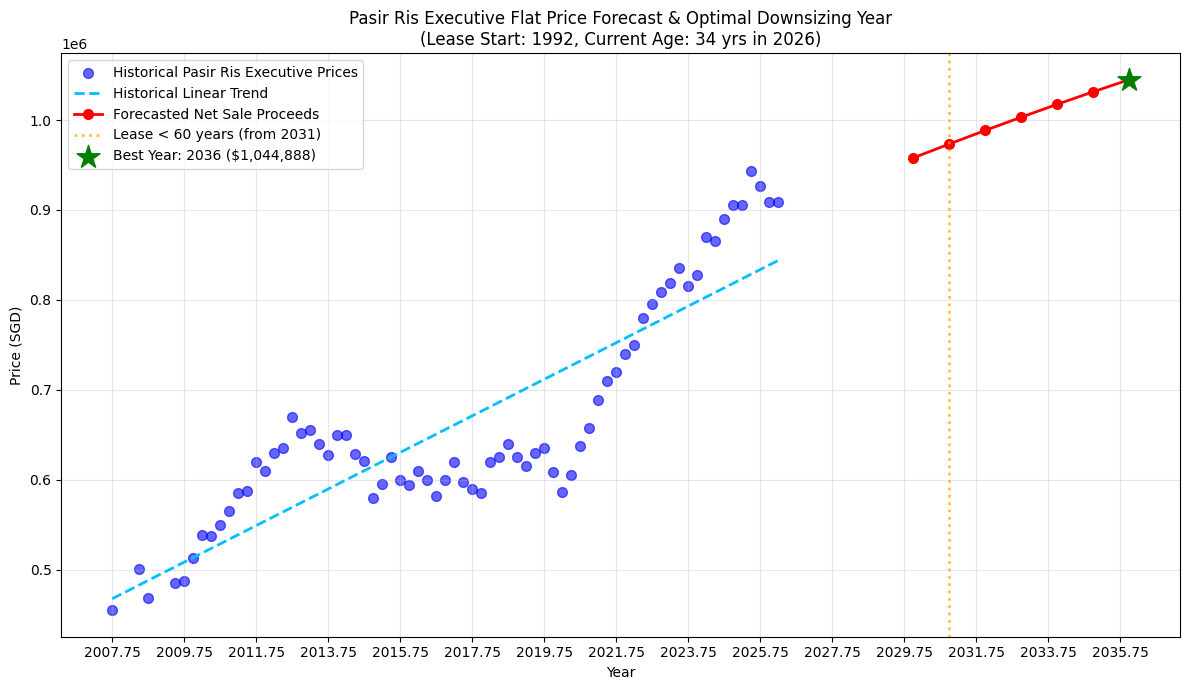

Visualization complete.


In [ ]:
print("--- Generating Visualization ---")

plt.figure(figsize=(12, 7))

# Plot historical data points
plt.scatter(historical_pasir_ris_prices_df["Year_Float"], historical_pasir_ris_prices_df["Price"],
            color="blue", label="Historical Pasir Ris Executive Prices", alpha=0.6, s=50)

# Plot historical trend line (from the linear regression model)
years_hist_range = np.linspace(historical_pasir_ris_prices_df["Year_Float"].min(),
                               historical_pasir_ris_prices_df["Year_Float"].max(), 100)
prices_trend_hist = linear_reg_model.predict(years_hist_range.reshape(-1, 1))
plt.plot(years_hist_range, prices_trend_hist, color="deepskyblue", linestyle="--",
         label="Historical Linear Trend", linewidth=2)

# Plot forecast (Adjusted Price for Mr. Chin's flat)
plt.plot(mr_chin_linear_forecast_df["Year"], mr_chin_linear_forecast_df["Projected_Net_Sale_Proceed"],
         color="red", marker="o", linestyle="-", label="Forecasted Net Sale Proceeds", linewidth=2, markersize=7)

# Add a vertical line for the 60-year lease threshold (e.g., 2032 for a 1992 commence date)
# Flat age 34 in 2026 implies lease commence 1992. 99-year lease. Lease expires 2091.
# 60 years remaining lease means year 2091 - 60 = 2031. So, after 2031 (i.e. 2032 onwards) is below 60 years.
lease_60_year_threshold = lease_start_year + lease_tenure - 60 # Year when remaining lease hits 60 years
plt.axvline(x=lease_60_year_threshold, color="orange", linestyle=":", alpha=0.7,
            label=f"Lease < 60 years (from {int(lease_60_year_threshold)})", linewidth=2)

# Highlight the best year to sell
best_year = int(mr_chin_linear_forecast_df.loc[mr_chin_linear_forecast_df['Projected_Net_Sale_Proceed'].idxmax()]['Year'])
best_proceeds = mr_chin_linear_forecast_df['Projected_Net_Sale_Proceed'].max()
plt.scatter(best_year, best_proceeds, color='green', marker='*', s=300, zorder=5,
            label=f'Best Year: {best_year} (${best_proceeds:,.0f})')


# Labels and formatting
plt.xlabel("Year")
plt.ylabel("Price (SGD)")
plt.title(f"Pasir Ris Executive Flat Price Forecast & Optimal Downsizing Year\n(Lease Start: {lease_start_year}, Current Age: {flat_age_current} yrs in {current_year})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(historical_pasir_ris_prices_df["Year_Float"].min(), forecast_years[-1] + 1, 2))
plt.tight_layout()

plt.show()
print("Visualization complete.")

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['town', 'flat_type', 'block', 'street_name',
                                  'storey_range', 'flat_model',
                                  'remaining_lease']),
                                ('num', StandardScaler(),
                                 ['floor_area_sqm', 'lease_commence_date',
                                  'transaction_year', 'transaction_month_num',
                                  'remaining_lease_years',
                                  'age_of_flat_at_transaction', 'price_per_sqm',
                                  'storey_range_group'])])

In [ ]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=5))
])

baseline_model.fit(X_train, y_train)
print('Baseline model trained.')

Baseline model trained.


In [ ]:
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

baseline_results = pd.DataFrame({
    'Model': ['Baseline Decision Tree'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2': [r2]
})

display(baseline_results.round(3))

# This cell uses the trained baseline model to predict laptop prices on the test set.
# y_pred stores the predicted prices.
# MAE shows the average absolute prediction error in dollars.
# RMSE also measures prediction error, but gives more penalty to large errors.
# R2 shows how much of the price variation is explained by the model.
# baseline_results stores the metrics in a simple table for comparison later.

,Model,MAE,RMSE,R2
0,Baseline Decision Tree,13868.756,20974.423,0.975


In [ ]:
error_df = X_test.copy()
error_df['Actual_Price_SGD'] = y_test.values
error_df['Predicted_Price_SGD'] = y_pred.round(2)
error_df['Absolute_Error'] = np.abs(error_df['Actual_Price_SGD'] - error_df['Predicted_Price_SGD']).round(2)

# Show largest errors first
error_df_sorted = error_df.sort_values('Absolute_Error', ascending=False)
display(error_df_sorted.head(10))

# This cell creates an error analysis table for the test set.
# It copies X_test so we can view each laptop together with its prediction result.
# Actual_Price_SGD stores the true price from y_test.
# Predicted_Price_SGD stores the model's predicted price.
# Absolute_Error shows how far the prediction is from the actual price.
# Sorting by Absolute_Error helps us inspect the worst prediction mistakes first.

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,price_per_sqm,storey_range_group,Actual_Price_SGD,Predicted_Price_SGD,Absolute_Error
65278,pasir ris,executive,160,pasir ris st 13,07 to 09,146.0,apartment,1995,74 years 01 month,2020,1,74,25,4006.849315,3,585000.0,750000.00,165000.00
76686,pasir ris,executive,646,pasir ris dr 10,07 to 09,146.0,apartment,1995,74 years 01 month,2020,8,74,25,4041.095890,3,590000.0,750000.00,160000.00
209848,pasir ris,executive,609,elias rd,13 to 15,155.0,apartment,1995,69 years 04 months,2025,4,69,30,6806.451613,5,1055000.0,979364.84,75635.16
183978,pasir ris,executive,547,pasir ris st 51,10 to 12,154.0,maisonette,1992,67 years 02 months,2024,11,67,32,6441.558442,4,992000.0,924957.79,67042.21
156392,pasir ris,executive,237,pasir ris st 21,13 to 15,159.0,apartment,1993,69 years 04 months,2023,3,69,30,5276.025157,5,838888.0,776411.90,62476.10
229872,pasir ris,executive,601,elias rd,10 to 12,154.0,apartment,1995,68 years 03 months,2026,1,68,31,6363.636364,4,980000.0,924957.79,55042.21
130709,pasir ris,executive,241,pasir ris st 21,10 to 12,158.0,apartment,1993,69 years 08 months,2022,12,69,29,5625.873418,4,888888.0,841779.50,47108.50
93513,pasir ris,executive,420,pasir ris dr 6,01 to 03,156.0,maisonette,1989,66 years 11 months,2021,3,66,32,4788.461538,1,747000.0,700077.90,46922.10
229904,pasir ris,executive,422,pasir ris dr 6,10 to 12,151.0,maisonette,1989,62 years 05 months,2026,6,62,37,6788.079470,4,1025000.0,979364.84,45635.16
21079,pasir ris,executive,605,elias rd,07 to 09,154.0,apartment,1995,76 years 02 months,2018,1,76,23,4188.311688,3,645000.0,601225.44,43774.56
